In [1]:
from pathlib import Path
import sys

import torch
from torch.utils.data import DataLoader

CWD = Path.cwd()
if (CWD / "ConvLSTM").exists():
    PROJECT_ROOT = CWD
    CONVLSTM_ROOT = CWD / "ConvLSTM"
elif (CWD / "trainConvLSTM.py").exists():
    CONVLSTM_ROOT = CWD
    PROJECT_ROOT = CWD.parent
else:
    raise RuntimeError("Cannot resolve project structure from current working directory.")

SQG_ROOT = PROJECT_ROOT / "SQG"
for path in (CONVLSTM_ROOT, SQG_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from convLSTM import ConvLSTMForecaster
from trainConvLSTM import train, plot_training_history, visualize_predictions, load_model_checkpoint, MODELS_DIR
from evalConvLSTM import test, compare_physical_predictions, compare_true_predictions
from dataset import NoiseDataset


/home/homeless/.virtualenvs/ts_lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_kwargs = dict(input_channels=1, hidden_channels=(16, 16), input_frames=10)
checkpoint_path = MODELS_DIR / "best_convlstm_ontrue.pt"
data_std = 2660.0
data_root = PROJECT_ROOT / "data"

train_dataset = NoiseDataset(
    folder_path=str(data_root / "sqg_subset"),
    split="train",
    mean=0.0,
    std=data_std,
)
val_dataset = NoiseDataset(
    folder_path=str(data_root / "sqg_subset"),
    split="val",
    mean=0.0,
    std=data_std,
)
test_dataset = NoiseDataset(
    folder_path=str(data_root / "sqg_subset"),
    split="test",
    mean=0.0,
    std=data_std,
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


NoiseDataset[train] loaded: 80 trajectories, 7280 samples, history=10, horizon=1, level=0
NoiseDataset[val] loaded: 10 trajectories, 910 samples, history=10, horizon=1, level=0
NoiseDataset[test] loaded: 10 trajectories, 910 samples, history=10, horizon=1, level=0


In [ ]:
model = ConvLSTMForecaster(**model_kwargs)
model, history = train(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=100,
    patience=10,
    save_path=checkpoint_path,
)
plot_training_history(history)
visualize_predictions(model, val_loader, device, num_examples=3)


/home/homeless/ResearchProject/ConvLSTM/trainConvLSTM.py:207: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=device)


Test latent loss: 0.019354
[RMSE] overall = 354.393890


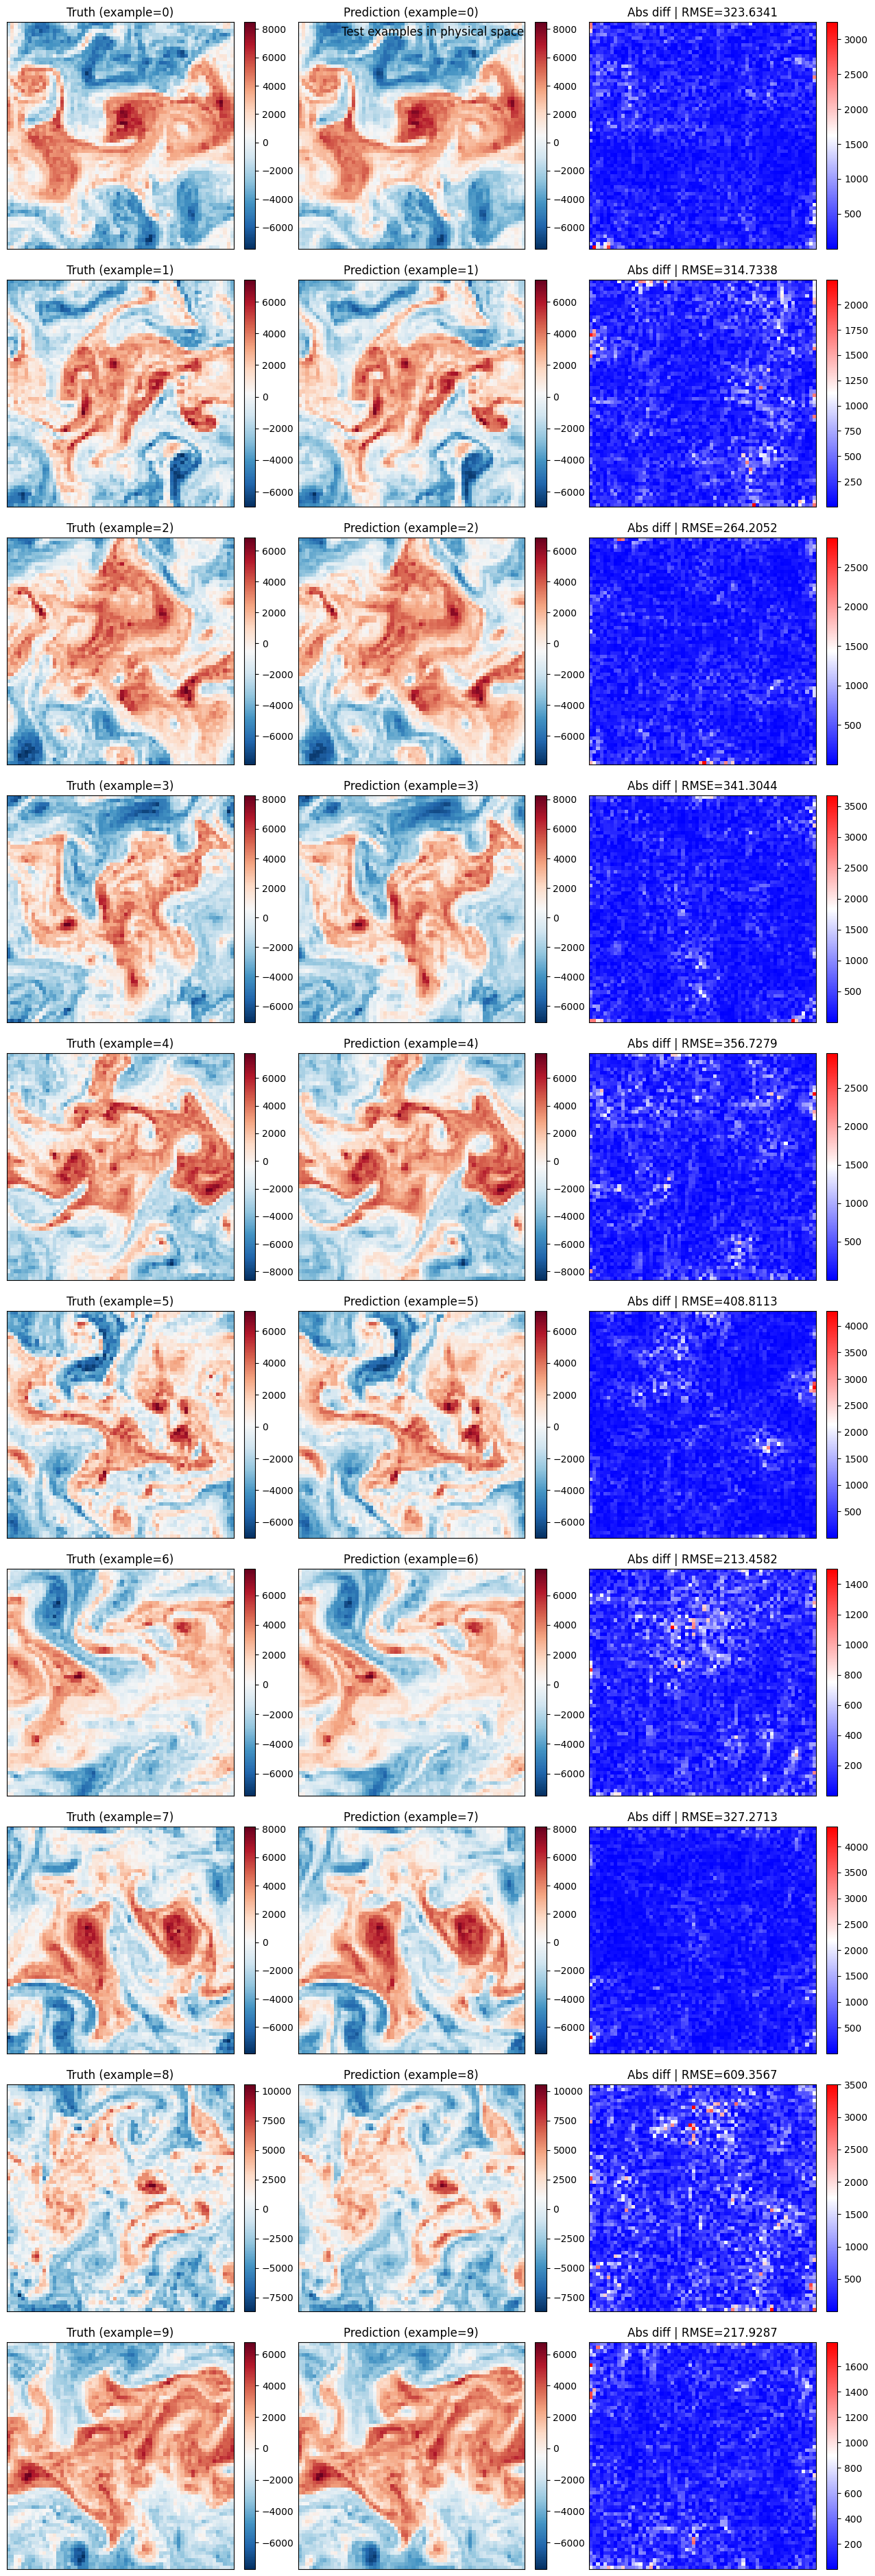

dataset_idx=0 | traj_id=69 | target_idx=10 | source_file=sqg_N64_3hrly_1057.npy | physical_RMSE=323.6341
dataset_idx=101 | traj_id=78 | target_idx=20 | source_file=sqg_N64_3hrly_1066.npy | physical_RMSE=314.7338
dataset_idx=202 | traj_id=59 | target_idx=30 | source_file=sqg_N64_3hrly_1047.npy | physical_RMSE=264.2052
dataset_idx=303 | traj_id=54 | target_idx=40 | source_file=sqg_N64_3hrly_1042.npy | physical_RMSE=341.3044
dataset_idx=404 | traj_id=29 | target_idx=50 | source_file=sqg_N64_3hrly_1017.npy | physical_RMSE=356.7279
dataset_idx=505 | traj_id=41 | target_idx=60 | source_file=sqg_N64_3hrly_1029.npy | physical_RMSE=408.8113
dataset_idx=606 | traj_id=56 | target_idx=70 | source_file=sqg_N64_3hrly_1044.npy | physical_RMSE=213.4582
dataset_idx=707 | traj_id=33 | target_idx=80 | source_file=sqg_N64_3hrly_1021.npy | physical_RMSE=327.2713
dataset_idx=808 | traj_id=79 | target_idx=90 | source_file=sqg_N64_3hrly_1067.npy | physical_RMSE=609.3567
dataset_idx=909 | traj_id=95 | target_i

In [3]:
model = load_model_checkpoint(checkpoint_path=checkpoint_path, device=device, model_kwargs=model_kwargs)

test_metrics = test(model, test_loader, device)
physical_compare = compare_true_predictions(
    model,
    test_dataset,
    device,
    num_examples=10,
)
